# 01 — Preprocesamiento

**Grupo 10 — Minería de Datos**

Corrige los problemas metodológicos del Hito 1 y prepara las features
para cada uno de los 4 experimentos.

## Correcciones respecto al Hito 1
| # | Problema | Solución |
|---|----------|----------|
| 1 | `CODIGO_REGION_DOMICILIO` tratada como numérica | Se elimina del clustering y se analiza post-hoc |
| 2 | `PTJE_NEM` y `PTJE_RANKING` colineales | Se prueba con/sin NEM; se elige la mejor combinación |
| 3 | `RAMA_EDUCACIONAL` no usada | Se agrega como feature binaria `es_tecnico` |
| 4 | Hipótesis sin formalizar | Se definen hipótesis concretas para cada pregunta |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

DATA_PROC = Path('../data/processed')

# Cargar datos procesados del notebook anterior
df_base = pd.read_parquet(DATA_PROC / 'df_base.parquet')
df_completo = pd.read_parquet(DATA_PROC / 'df_completo.parquet')

print(f'df_base:     {len(df_base):,} filas')
print(f'df_completo: {len(df_completo):,} filas')

df_base:     198,304 filas
df_completo: 136,156 filas


## 1. Análisis de colinealidad NEM / Ranking

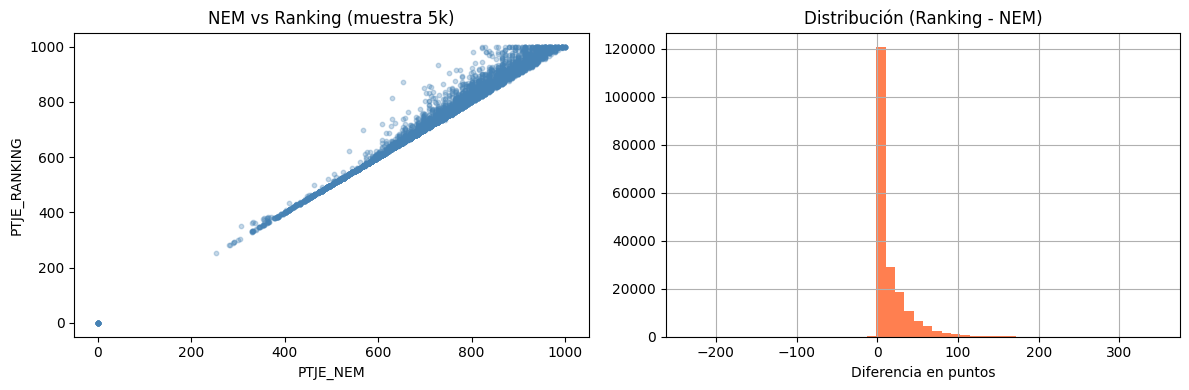

Correlación NEM ↔ Ranking: 0.9911
Casos donde NEM = Ranking (ranking < NEM → se reemplaza): 39.0%

DECISIÓN: usar solo PTJE_RANKING (siempre ≥ NEM, más informativo)


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter NEM vs Ranking
muestra = df_base.sample(5000, random_state=42)
axes[0].scatter(muestra['PTJE_NEM'], muestra['PTJE_RANKING'], 
                alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('PTJE_NEM')
axes[0].set_ylabel('PTJE_RANKING')
axes[0].set_title('NEM vs Ranking (muestra 5k)')

# Diferencia
diff = df_base['PTJE_RANKING'] - df_base['PTJE_NEM']
diff.hist(bins=50, ax=axes[1], color='coral')
axes[1].set_title('Distribución (Ranking - NEM)')
axes[1].set_xlabel('Diferencia en puntos')

plt.tight_layout()
plt.show()

corr = df_base[['PTJE_NEM', 'PTJE_RANKING']].corr().iloc[0,1]
iguales = (df_base['PTJE_NEM'] == df_base['PTJE_RANKING']).mean() * 100
print(f'Correlación NEM ↔ Ranking: {corr:.4f}')
print(f'Casos donde NEM = Ranking (ranking < NEM → se reemplaza): {iguales:.1f}%')
print()
print('DECISIÓN: usar solo PTJE_RANKING (siempre ≥ NEM, más informativo)')

## 2. Features para P1 — Clustering

In [3]:
# Features corregidas para clustering
# Se EXCLUYE codigo_region_domicilio (nominal → distorsiona distancia euclidiana)
# Se EXCLUYE ptje_nem (colineal con ptje_ranking)
# Se AGREGA es_tecnico (rama educacional)

FEATURES_CLUSTERING = [
    'CLEC_MAX',
    'MATE1_MAX',
    'PTJE_RANKING',
    'DEPENDENCIA',
    'INGRESO_PERCAPITA_GRUPO_FA',
    'es_tecnico',
]

df_cluster = df_base[FEATURES_CLUSTERING].dropna()
print(f'Dataset para clustering: {len(df_cluster):,} filas')
print(f'Features: {FEATURES_CLUSTERING}')

# Escalar
scaler = StandardScaler()
X_cluster = scaler.fit_transform(df_cluster)
print('\nEstadísticas tras StandardScaler (deben ser ~0 media, ~1 std):')
print(pd.DataFrame(X_cluster, columns=FEATURES_CLUSTERING).describe().round(3))

Dataset para clustering: 198,304 filas
Features: ['CLEC_MAX', 'MATE1_MAX', 'PTJE_RANKING', 'DEPENDENCIA', 'INGRESO_PERCAPITA_GRUPO_FA', 'es_tecnico']

Estadísticas tras StandardScaler (deben ser ~0 media, ~1 std):
         CLEC_MAX   MATE1_MAX  PTJE_RANKING  DEPENDENCIA  \
count  198304.000  198304.000    198304.000   198304.000   
mean       -0.000      -0.000         0.000        0.000   
std         1.000       1.000         1.000        1.000   
min        -4.192      -3.637        -4.478       -1.806   
25%        -0.833      -0.627        -0.712       -0.884   
50%        -0.106      -0.119         0.044        0.039   
75%         0.713       0.554         0.782        0.039   
max         3.328       2.266         1.667        2.805   

       INGRESO_PERCAPITA_GRUPO_FA  es_tecnico  
count                  198304.000  198304.000  
mean                       -0.000       0.000  
std                         1.000       1.000  
min                        -1.262      -0.560  
25%  

In [4]:
# Guardar features de clustering
import joblib

np.save(DATA_PROC / 'X_cluster.npy', X_cluster)
joblib.dump(scaler, DATA_PROC / 'scaler_cluster.pkl')
df_base[FEATURES_CLUSTERING + ['CODIGO_REGION_DOMICILIO', 'RAMA_EDUCACIONAL', 
                                 'CODIGO_REGION_EGRESO']].to_parquet(
    DATA_PROC / 'df_cluster_base.parquet', index=False)

print('Guardado:')
print('  X_cluster.npy           → matriz escalada para clustering')
print('  scaler_cluster.pkl      → scaler para inverter transformación')
print('  df_cluster_base.parquet → datos con variables adicionales para análisis post-hoc')

Guardado:
  X_cluster.npy           → matriz escalada para clustering
  scaler_cluster.pkl      → scaler para inverter transformación
  df_cluster_base.parquet → datos con variables adicionales para análisis post-hoc


## 3. Features para P2 — Regresión

In [5]:
# Variable objetivo: CLEC_MAX (lenguaje) — se puede repetir con MATE1_MAX
# Variables predictoras: SOLO socioeconómicas y de escolaridad (NO otros puntajes)

# Codificar región como categórica (one-hot)
df_reg = df_base[[
    'CLEC_MAX', 'MATE1_MAX',
    'INGRESO_PERCAPITA_GRUPO_FA',
    'DEPENDENCIA',
    'es_tecnico',
    'CODIGO_REGION_DOMICILIO',
    'PTJE_RANKING',  # proxy de notas contextualizadas
]].dropna()

# One-hot encoding de región (la correcta para variables nominales)
df_reg_encoded = pd.get_dummies(
    df_reg, 
    columns=['CODIGO_REGION_DOMICILIO'],
    prefix='region',
    drop_first=True  # evitar multicolinealidad perfecta
)

print(f'Dataset para regresión: {len(df_reg_encoded):,} filas')
print(f'Columnas tras one-hot: {df_reg_encoded.shape[1]}')

df_reg_encoded.to_parquet(DATA_PROC / 'df_regresion.parquet', index=False)
print('Guardado: df_regresion.parquet')

Dataset para regresión: 198,304 filas
Columnas tras one-hot: 21
Guardado: df_regresion.parquet


## 4. Features para P3 — Clasificación multiclase

In [6]:
# Variable objetivo: TIPO_INST_2 (CFT / IP / U.CRUCH / U.Privada)
print('Distribución de tipo de institución:')
print(df_completo['TIPO_INST_2'].value_counts())
print()
print('Distribución relativa:')
print(df_completo['TIPO_INST_2'].value_counts(normalize=True).round(3))

Distribución de tipo de institución:
TIPO_INST_2
Universidades CRUCH             63277
Universidades Privadas          42772
Institutos Profesionales        18868
Centros de Formación Técnica    11239
Name: count, dtype: int64

Distribución relativa:
TIPO_INST_2
Universidades CRUCH             0.465
Universidades Privadas          0.314
Institutos Profesionales        0.139
Centros de Formación Técnica    0.083
Name: proportion, dtype: float64


In [7]:
FEATURES_CLASIF = [
    'CLEC_MAX',
    'MATE1_MAX', 
    'PTJE_RANKING',
    'INGRESO_PERCAPITA_GRUPO_FA',
    'DEPENDENCIA',
    'es_tecnico',
    'TIPO_INST_2',  # variable objetivo
]

df_clasif = df_completo[FEATURES_CLASIF].dropna()

# Verificar desbalance de clases
print(f'Dataset para clasificación: {len(df_clasif):,} filas')
desbalance = df_clasif['TIPO_INST_2'].value_counts(normalize=True)
print('\nBalance de clases:')
for clase, prop in desbalance.items():
    barra = '█' * int(prop * 40)
    print(f'  {clase[:20]:<20} {prop*100:5.1f}% {barra}')

if desbalance.max() > 0.5:
    print('\n⚠️  Desbalance significativo → usar class_weight="balanced" en los modelos')

df_clasif.to_parquet(DATA_PROC / 'df_clasificacion.parquet', index=False)
print('\nGuardado: df_clasificacion.parquet')

Dataset para clasificación: 136,156 filas

Balance de clases:
  Universidades CRUCH   46.5% ██████████████████
  Universidades Privad  31.4% ████████████
  Institutos Profesion  13.9% █████
  Centros de Formación   8.3% ███

Guardado: df_clasificacion.parquet


## 5. Features para P4 — Clasificación binaria (migración)

In [8]:
# Variable objetivo: migra (0/1)
print('Distribución de migración estudiantil:')
conteo = df_completo['migra'].value_counts()
print(f'  No migra (0): {conteo[0]:,} ({conteo[0]/len(df_completo)*100:.1f}%)')
print(f'  Migra    (1): {conteo[1]:,} ({conteo[1]/len(df_completo)*100:.1f}%)')

tasa_migracion = df_completo.groupby('CODIGO_REGION_DOMICILIO')['migra'].mean().sort_values(ascending=False)
print('\nTasa de migración por región de domicilio (top 5):')
print(tasa_migracion.head())

Distribución de migración estudiantil:
  No migra (0): 116,600 (85.6%)
  Migra    (1): 19,556 (14.4%)

Tasa de migración por región de domicilio (top 5):
CODIGO_REGION_DOMICILIO
11    0.671355
6     0.540097
3     0.386219
16    0.361629
10    0.297710
Name: migra, dtype: float64


In [9]:
FEATURES_MIGRACION = [
    'CLEC_MAX',
    'MATE1_MAX',
    'PTJE_RANKING',
    'INGRESO_PERCAPITA_GRUPO_FA',
    'DEPENDENCIA',
    'es_tecnico',
    'CODIGO_REGION_DOMICILIO',  # aquí sí como categórica
    'migra',  # variable objetivo
]

df_migracion = df_completo[FEATURES_MIGRACION].dropna()

# One-hot encoding de región
df_migracion_enc = pd.get_dummies(
    df_migracion,
    columns=['CODIGO_REGION_DOMICILIO'],
    prefix='region',
    drop_first=True
)

print(f'Dataset para migración: {len(df_migracion_enc):,} filas')
df_migracion_enc.to_parquet(DATA_PROC / 'df_migracion.parquet', index=False)
print('Guardado: df_migracion.parquet')

Dataset para migración: 136,156 filas
Guardado: df_migracion.parquet


## 6. Resumen de datasets listos para experimentos

| Archivo | Filas | Uso |
|---------|-------|-----|
| `df_base.parquet` | ~194k | Exploración general |
| `X_cluster.npy` | ~194k | P1 — Clustering (ya escalado) |
| `df_regresion.parquet` | ~194k | P2 — Regresión |
| `df_clasificacion.parquet` | ~100k | P3 — Tipo de institución |
| `df_migracion.parquet` | ~100k | P4 — Migración estudiantil |

**Próximo paso:** `02_P1_clustering.ipynb`